<a href="https://www.kaggle.com/code/lalit7881/retails-sales-analysis-eda?scriptVersionId=348946364" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/udaykumar025/retails-sales-analysis/retail_sales_analysis.ipynb
/kaggle/input/datasets/udaykumar025/retails-sales-analysis/Retail Sales Analysis/Retail Sales Analysis/clander.csvZone.Identifier
/kaggle/input/datasets/udaykumar025/retails-sales-analysis/Retail Sales Analysis/Retail Sales Analysis/product.csvZone.Identifier
/kaggle/input/datasets/udaykumar025/retails-sales-analysis/Retail Sales Analysis/Retail Sales Analysis/customer.csvZone.Identifier
/kaggle/input/datasets/udaykumar025/retails-sales-analysis/Retail Sales Analysis/Retail Sales Analysis/clander.csv
/kaggle/input/datasets/udaykumar025/retails-sales-analysis/Retail Sales Analysis/Retail Sales Analysis/order.csvZone.Identifier
/kaggle/input/datasets/udaykumar025/retails-sales-analysis/Retail Sales Analysis/Retail Sales Analysis/archive (3).zipZone.Identifier
/kaggle/input/datasets/udaykumar025/retails-sales-analysis/Retail Sales Analysis/Retail Sales Analysis/order.csv
/kaggle/input/datasets/uday

## Loading dataset

In [2]:
import os

# ==============================
# 1. File paths
# ==============================
base = "/kaggle/input/datasets/udaykumar025/retails-sales-analysis/Retail Sales Analysis/Retail Sales Analysis"

files = {
    "customer": "customer.csv",
    "product": "product.csv",
    "order": "order.csv",
    "calendar": "clander.csv"
}

# ==============================
# 2. Load datasets
# ==============================
df = {}

for name, file in files.items():
    path = os.path.join(base, file)
    df[name] = pd.read_csv(path)
    print(f"{name}: {df[name].shape}")

# ==============================
# 3. Basic cleaning
# ==============================
for name in df:
    df[name].columns = (
        df[name].columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    
    df[name] = df[name].drop_duplicates()
    df[name] = df[name].dropna(how="all")

# ==============================
# 4. Dataset information
# ==============================
for name, data in df.items():
    print("\n" + "=" * 50)
    print(name.upper())
    print("=" * 50)
    print("Shape:", data.shape)
    print("Columns:", list(data.columns))
    print("\nMissing values:")
    print(data.isnull().sum())
    print("\nSummary:")
    display(data.describe(include="all").T)

# ==============================
# 5. Convert date columns
# ==============================
for name, data in df.items():
    for col in data.columns:
        if "date" in col or "day" in col:
            try:
                data[col] = pd.to_datetime(data[col], errors="coerce")
            except:
                pass

# ==============================
# 6. Numeric and categorical columns
# ==============================
for name, data in df.items():
    numeric_cols = data.select_dtypes(include="number").columns.tolist()
    categorical_cols = data.select_dtypes(include="object").columns.tolist()

    print(f"\n{name.upper()}")
    print("Numeric columns:", numeric_cols)
    print("Categorical columns:", categorical_cols)

# ==============================
# 7. Quick value counts
# ==============================
for name, data in df.items():
    print("\n", "=" * 50)
    print(f"{name.upper()} VALUE COUNTS")
    print("=" * 50)

    for col in data.select_dtypes(include="object").columns[:5]:
        print(f"\n{col}:")
        print(data[col].value_counts().head(10))

# ==============================
# 8. Correlation of numeric data
# ==============================
for name, data in df.items():
    numeric = data.select_dtypes(include="number")
    
    if not numeric.empty:
        print(f"\n{name.upper()} Correlation:")
        display(numeric.corr())

# ==============================
# 9. Create combined order analysis
# ==============================
orders = df["order"].copy()
customers = df["customer"].copy()
products = df["product"].copy()

print("\nORDER DATA SAMPLE")
display(orders.head())

# ==============================
# 10. Find common ID columns
# ==============================
print("\nCommon columns:")
print("Order ↔ Customer:",
      list(set(orders.columns) & set(customers.columns)))

print("Order ↔ Product:",
      list(set(orders.columns) & set(products.columns)))

# ==============================
# 11. Automatic sales summary
# ==============================
numeric_cols = orders.select_dtypes(include="number").columns.tolist()

print("\nOrder numeric columns:")
print(numeric_cols)

if numeric_cols:
    print("\nTotal / Average:")
    print(orders[numeric_cols].agg(["sum", "mean", "min", "max"]).T)

# ==============================
# 12. Final cleaned datasets
# ==============================
customer = df["customer"]
product = df["product"]
order = df["order"]
calendar = df["calendar"]

print("\nFinal datasets:")
print("Customer :", customer.shape)
print("Product  :", product.shape)
print("Order    :", order.shape)
print("Calendar :", calendar.shape)

customer: (1000, 10)
product: (1000, 9)
order: (1000, 13)
calendar: (1000, 10)

CUSTOMER
Shape: (1000, 10)
Columns: ['customerid', 'firstname', 'lastname', 'email', 'phonenumber', 'address', 'unnamed:_6', 'country', 'dateofbirth', 'gender']

Missing values:
customerid        0
firstname         0
lastname          0
email             0
phonenumber       0
address           0
unnamed:_6     1000
country           0
dateofbirth       0
gender            0
dtype: int64

Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerid,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
firstname,1000,954,Briant,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lastname,1000,993,Prigmore,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email,1000,1000,mcarlesrr@go.com,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phonenumber,1000,1000,964-392-2657,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address,1000,1000,788 Anhalt Road,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unnamed:_6,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1000,129,China,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dateofbirth,1000,344,10/23/2023,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1000,8,Male,454,NaN,NaN,NaN,NaN,NaN,NaN,NaN



PRODUCT
Shape: (1000, 9)
Columns: ['productid', 'productname', 'category', 'supplierid', 'unitprice', 'unitsinstock', 'unitsonorder', 'reorderlevel', 'discontinued']

Missing values:
productid       0
productname     0
category        0
supplierid      0
unitprice       0
unitsinstock    0
unitsonorder    0
reorderlevel    0
discontinued    0
dtype: int64

Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
productid,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
productname,1000,10,Microwave,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1000,3,Clothing,356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplierid,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
unitprice,1000.0,NaN,NaN,NaN,496.63317,292.828055,1.84,238.24,487.56,757.37,999.34
unitsinstock,1000.0,NaN,NaN,NaN,4974.24,2887.43618,2.0,2445.75,5015.5,7490.0,9965.0
unitsonorder,1000.0,NaN,NaN,NaN,507.634,294.236478,2.0,245.75,510.0,771.25,1000.0
reorderlevel,1000.0,NaN,NaN,NaN,498.546,290.448126,0.0,244.5,502.5,755.0,1000.0
discontinued,1000,2,True,508,NaN,NaN,NaN,NaN,NaN,NaN,NaN



ORDER
Shape: (1000, 13)
Columns: ['orderid', 'customerid', 'orderdate', 'orderstatus', 'shippeddate', 'shipaddress', 'unnamed:_6', 'unnamed:_7', 'unnamed:_8', 'shipcountry', 'shippingfee', 'paymentmethod', 'totalamount']

Missing values:
orderid             0
customerid          0
orderdate           0
orderstatus         0
shippeddate         0
shipaddress         0
unnamed:_6       1000
unnamed:_7       1000
unnamed:_8       1000
shipcountry         0
shippingfee         0
paymentmethod       0
totalamount         0
dtype: int64

Summary:


...


CALENDAR Correlation:


,month,year,quarter,week_number,unnamed:_7,unnamed:_8
month,1.000000,-0.017204,0.021442,0.016151,NaN,NaN
year,-0.017204,1.000000,-0.018856,-0.022959,NaN,NaN
quarter,0.021442,-0.018856,1.000000,0.024810,NaN,NaN
week_number,0.016151,-0.022959,0.024810,1.000000,NaN,NaN
unnamed:_7,NaN,NaN,NaN,NaN,NaN,NaN
unnamed:_8,NaN,NaN,NaN,NaN,NaN,NaN



ORDER DATA SAMPLE


,orderid,customerid,orderdate,orderstatus,shippeddate,shipaddress,unnamed:_6,unnamed:_7,unnamed:_8,shipcountry,shippingfee,paymentmethod,totalamount
0,1,1,2012-02-16,pending,2021-07-10,30249 Donald Way,NaN,NaN,NaN,China,63.95,cash on delivery,1568.28
1,2,2,2012-02-06,processing,2014-06-23,97 David Street,NaN,NaN,NaN,Greece,75.62,cash on delivery,4654.31
2,3,3,2013-01-02,pending,2022-10-22,2024 Myrtle Parkway,NaN,NaN,NaN,Poland,453.17,PayPal,5810.01
3,4,4,2013-02-28,pending,2011-11-22,75158 Merry Plaza,NaN,NaN,NaN,Japan,883.25,PayPal,4388.28
4,5,5,2014-08-28,delivered,2017-08-16,875 Nancy Hill,NaN,NaN,NaN,Portugal,881.14,credit card,2972.23



Common columns:
Order ↔ Customer: ['customerid', 'unnamed:_6']
Order ↔ Product: []

Order numeric columns:
['orderid', 'customerid', 'unnamed:_6', 'unnamed:_7', 'unnamed:_8', 'shippingfee', 'totalamount']

Total / Average:
                    sum        mean   min      max
orderid       500500.00   500.50000  1.00  1000.00
customerid    500500.00   500.50000  1.00  1000.00
unnamed:_6         0.00         NaN   NaN      NaN
unnamed:_7         0.00         NaN   NaN      NaN
unnamed:_8         0.00         NaN   NaN      NaN
shippingfee   505834.05   505.83405  0.41   999.93
totalamount  4850371.19  4850.37119  0.84  9979.46

Final datasets:
Customer : (1000, 10)
Product  : (1000, 9)
Order    : (1000, 13)
Calendar : (1000, 10)


## EDA

CUSTOMER: (1000, 9)
PRODUCT : (1000, 9)
ORDER   : (1000, 10)
CALENDAR: (1000, 8)


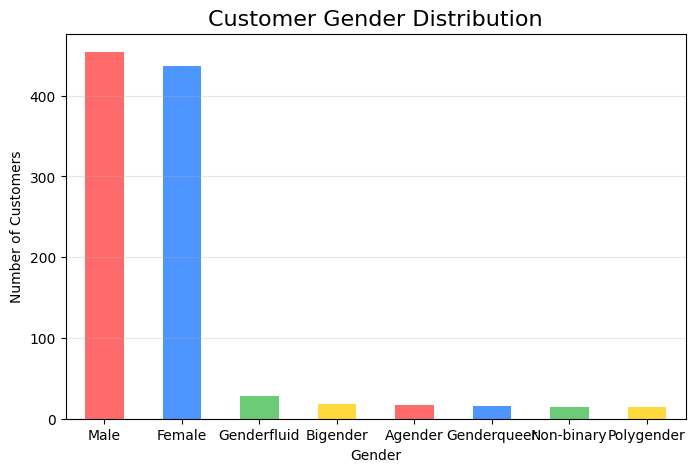

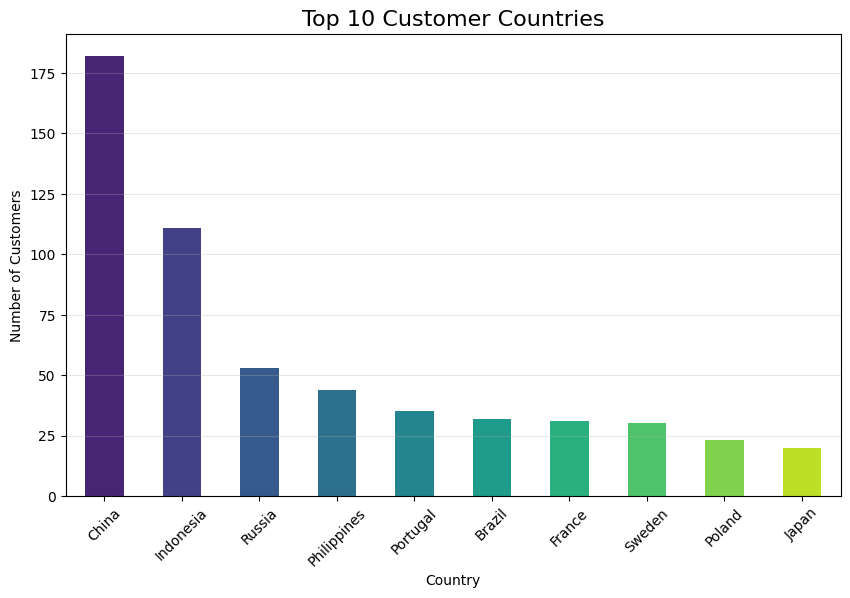

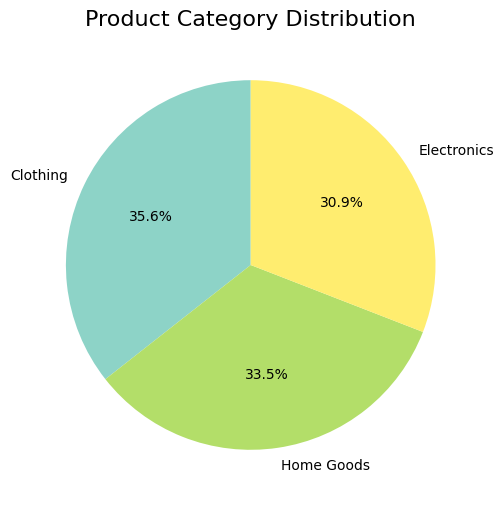

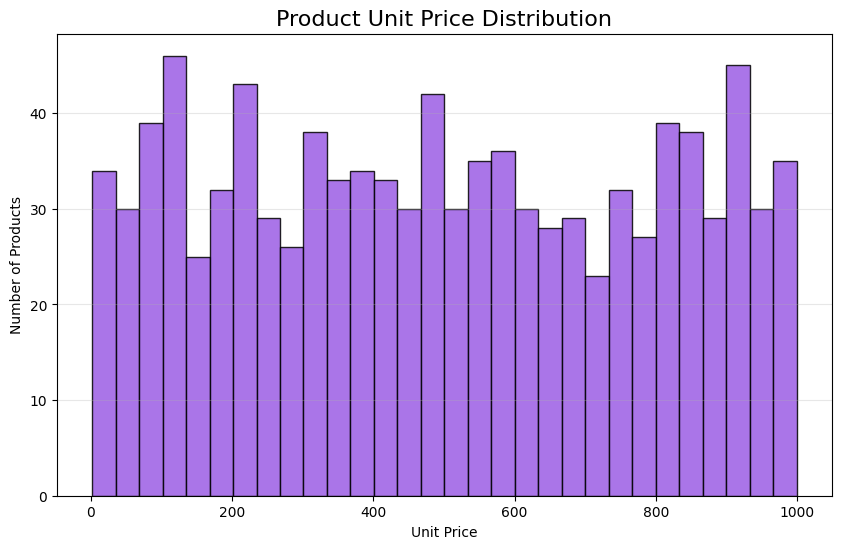

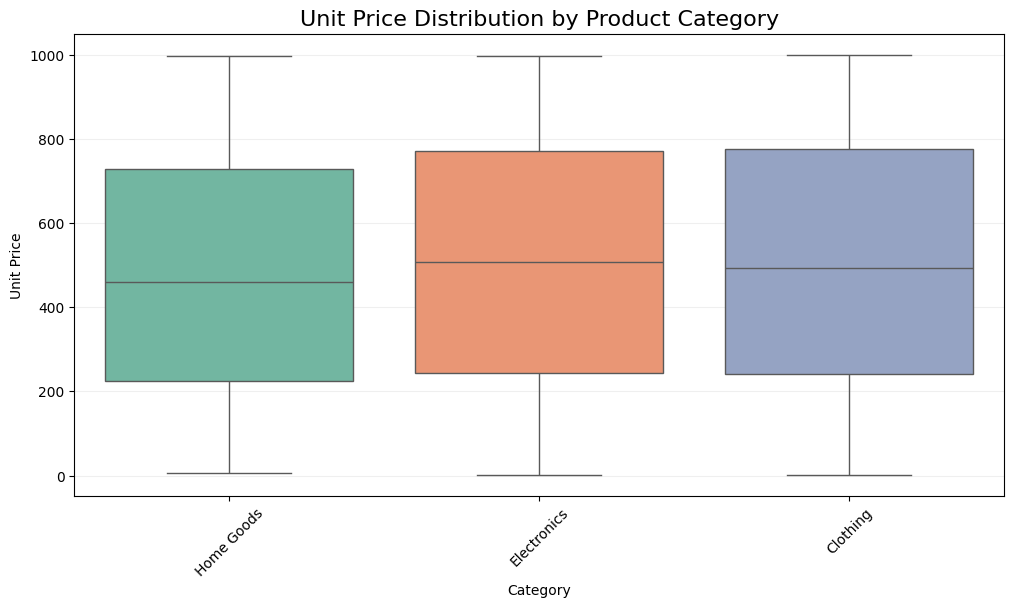

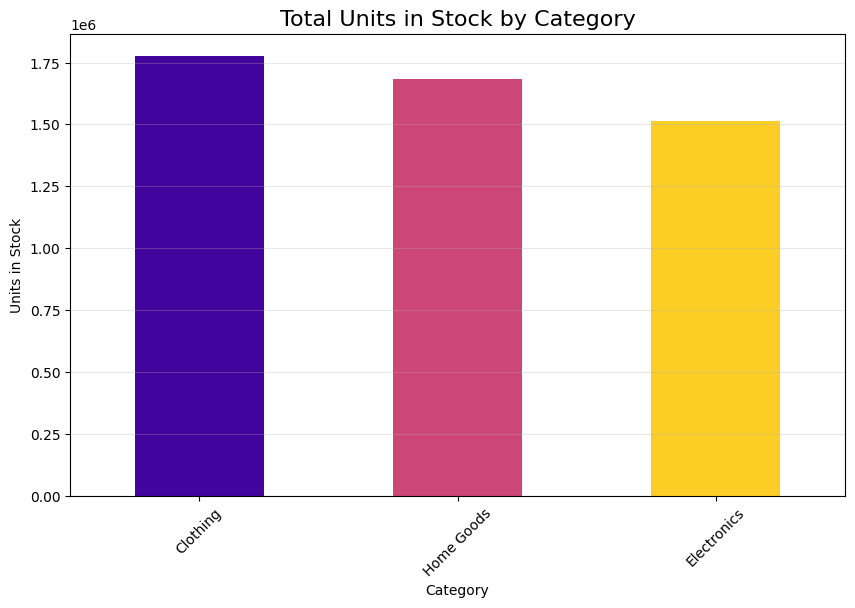

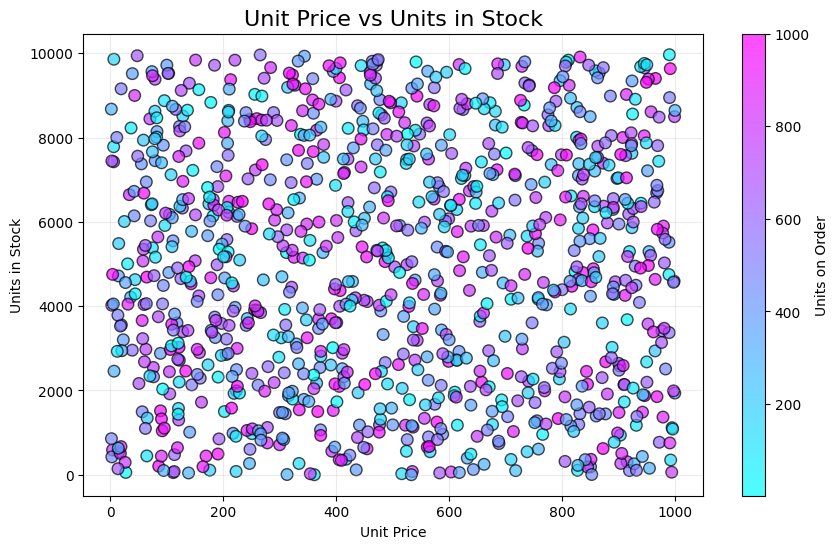

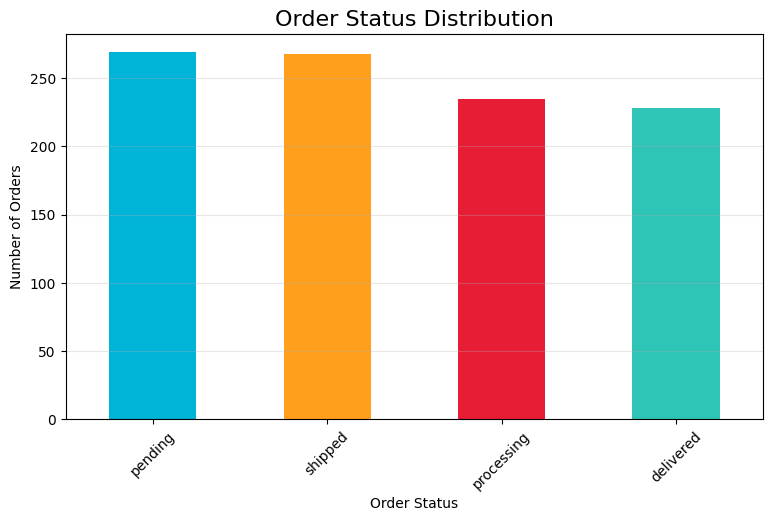

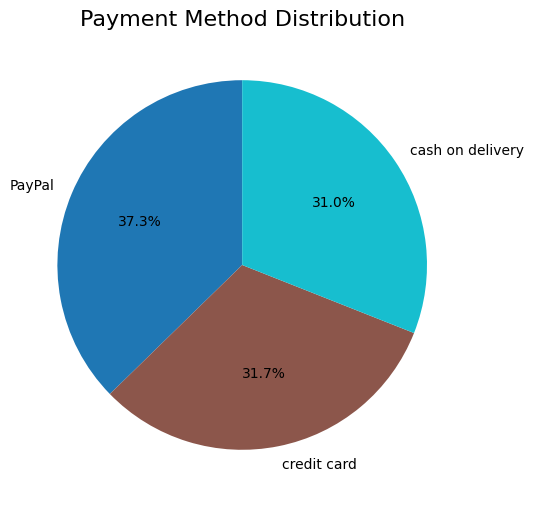

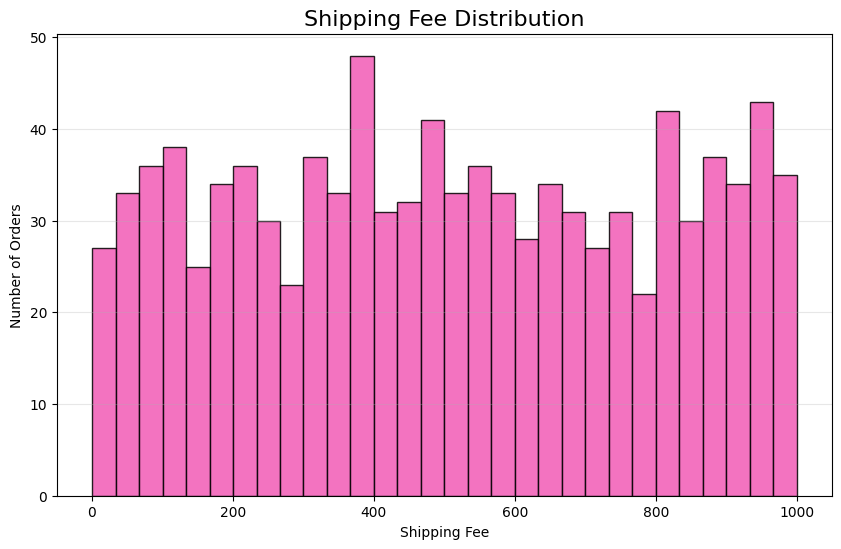

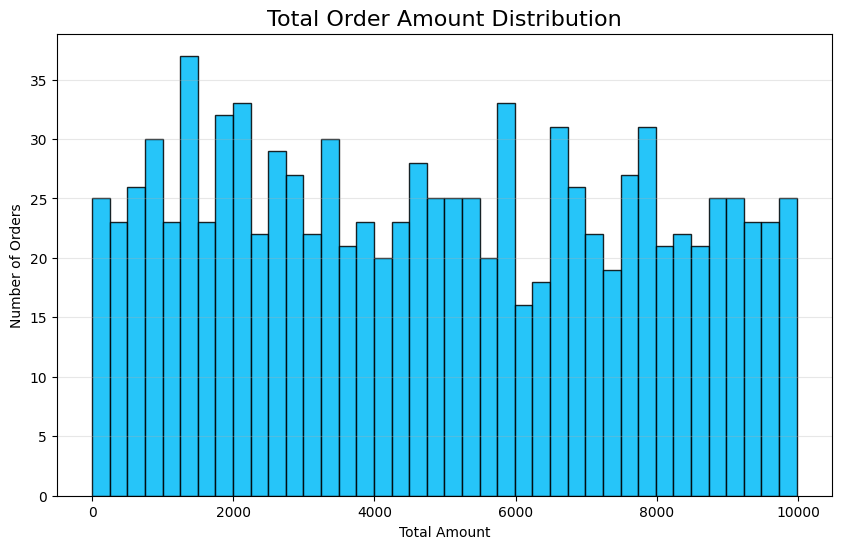

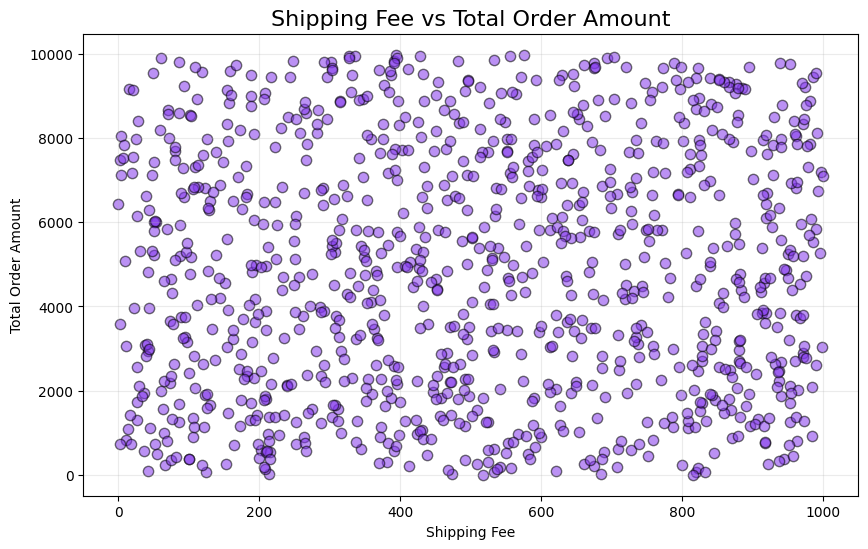

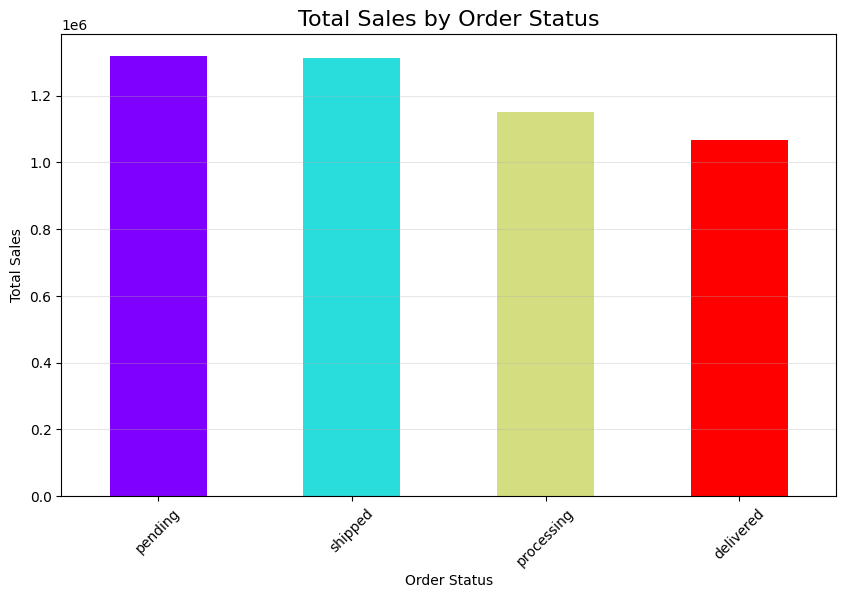

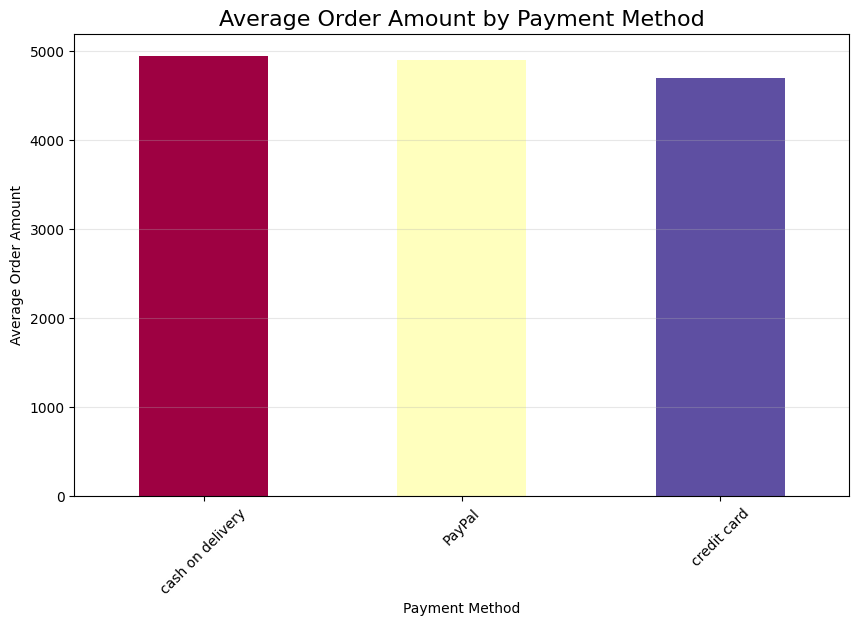

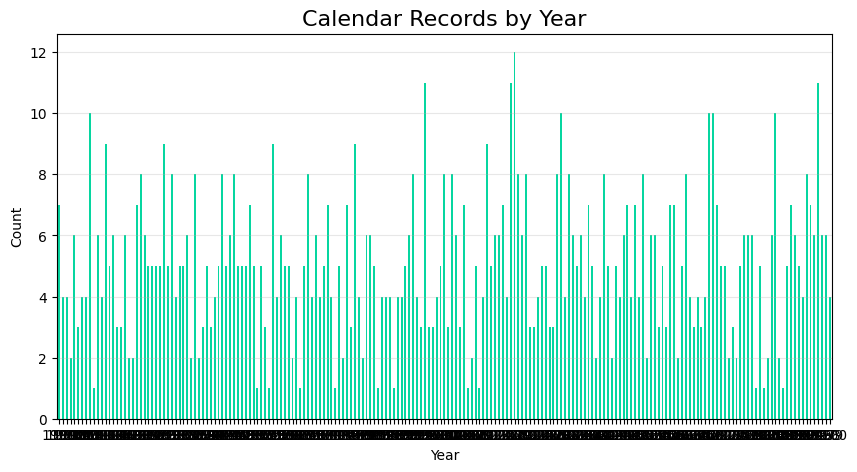

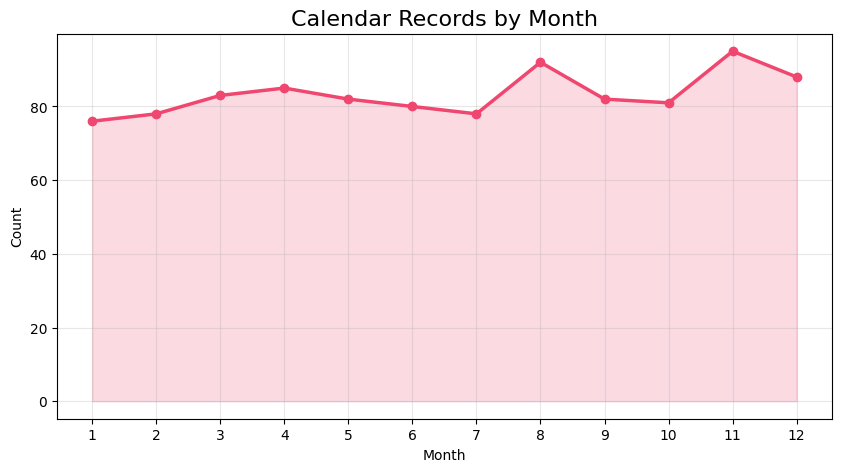

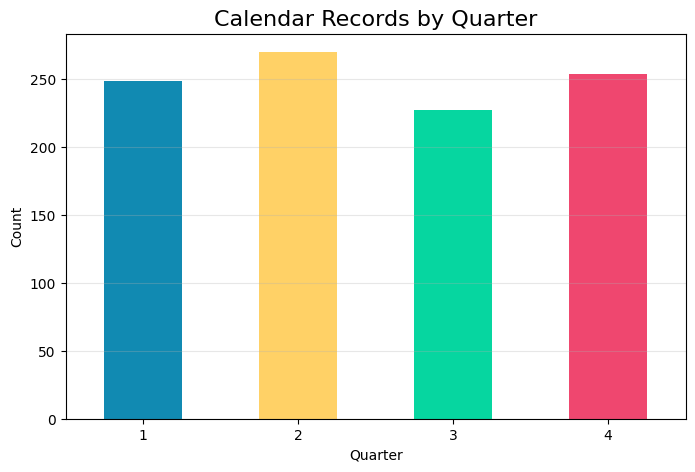

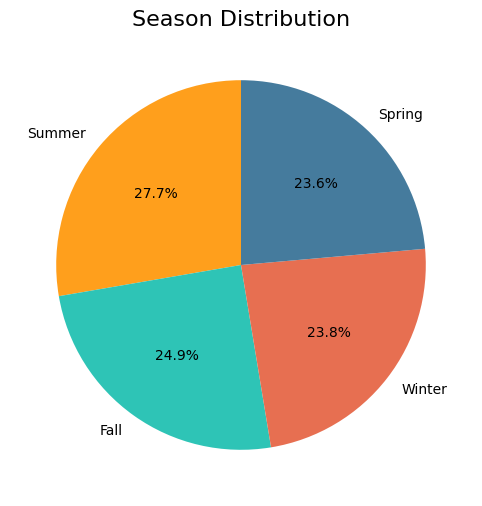

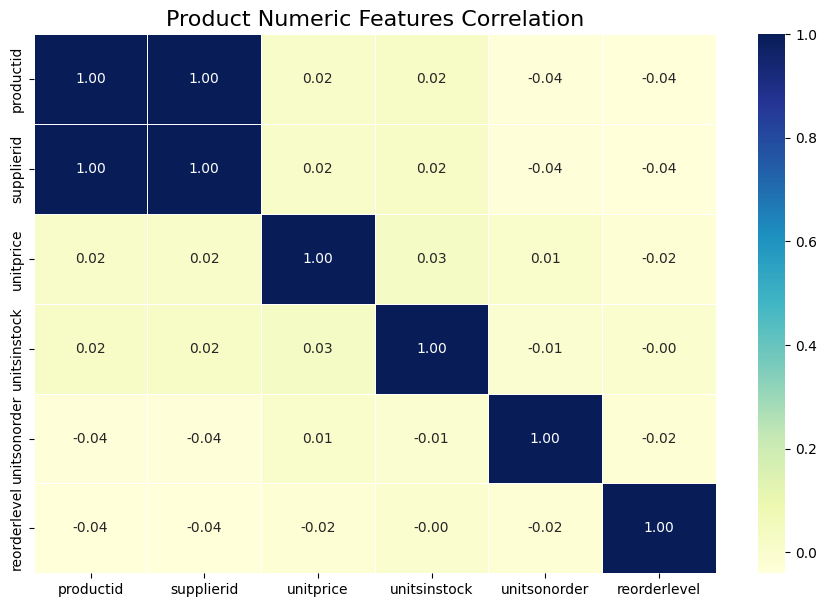

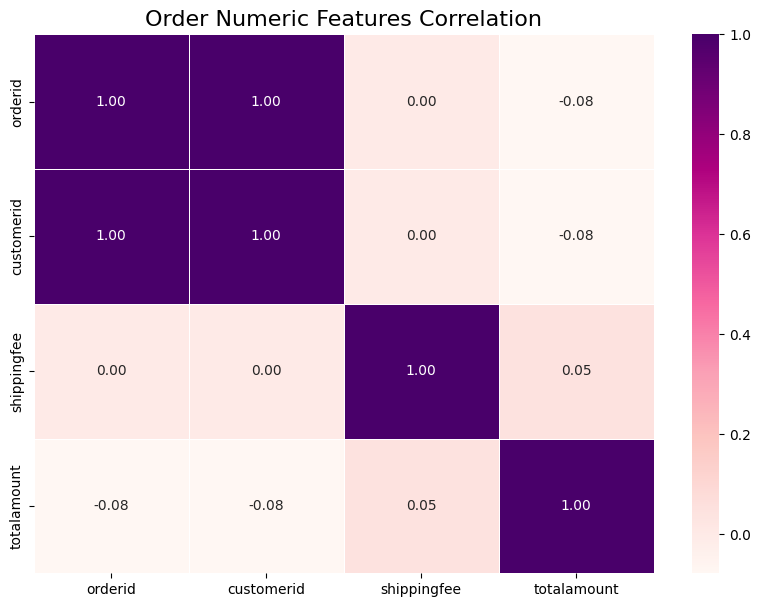

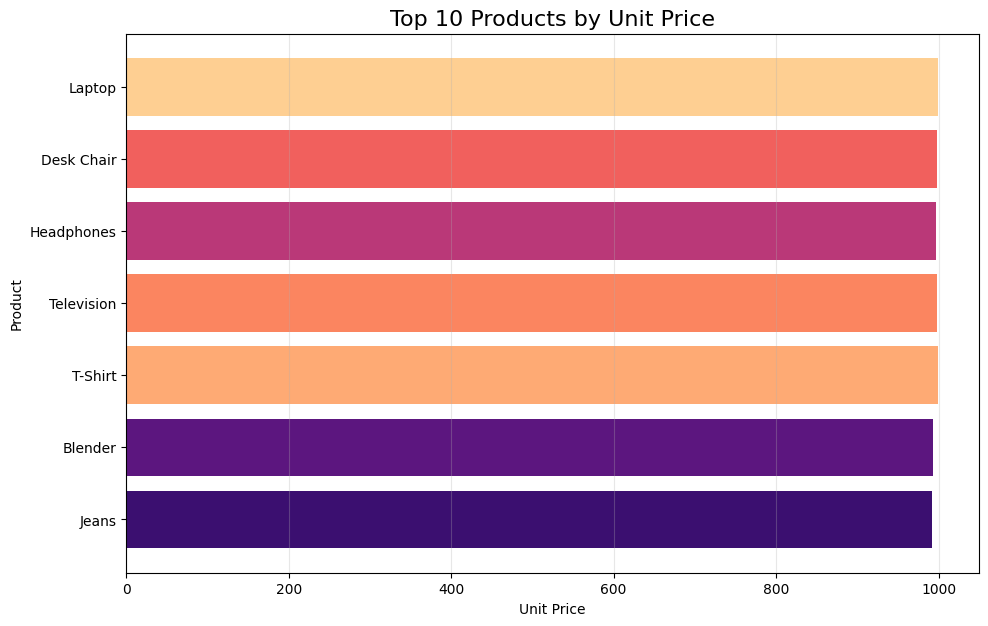

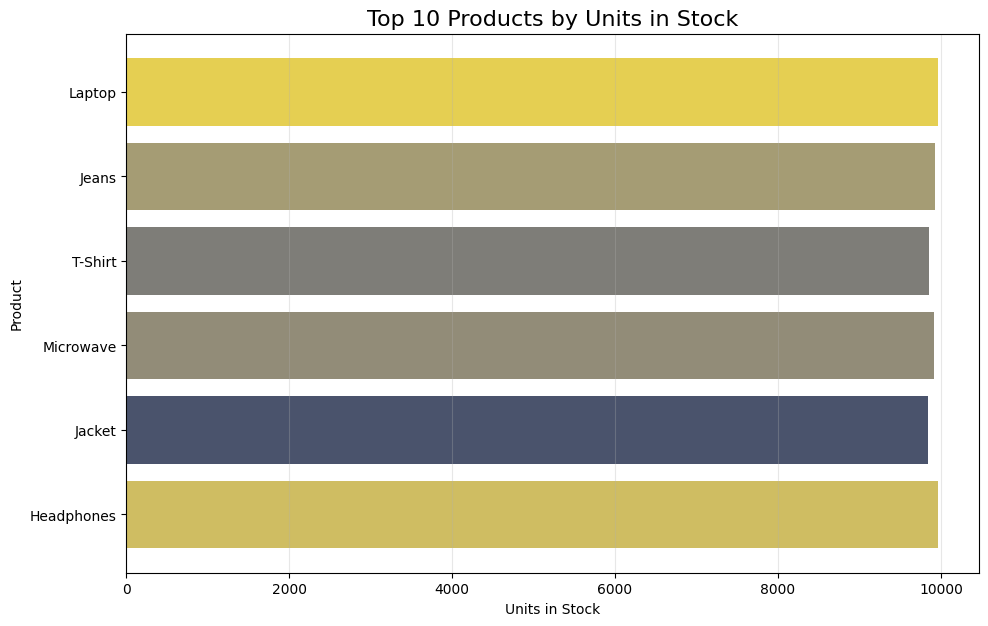


RETAIL SALES VISUALIZATION COMPLETED

Customer:
Customers: 1000
Countries: 129
Genders: 8

Product:
Products: 1000
Categories: 3
Average Unit Price: 496.63

Order:
Orders: 1000
Total Sales: 4850371.19
Average Order: 4850.37
Average Shipping Fee: 505.83

Calendar:
Years: 199
Months: 12
Quarters: 4


In [3]:
for data in [customer, product, order, calendar]:
    data.columns = (
        data.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    data.drop_duplicates(inplace=True)

# ------------------------------------------------------------
# 3. Remove unwanted unnamed columns
# ------------------------------------------------------------

customer = customer.drop(columns=["unnamed:_6"], errors="ignore")

order = order.drop(
    columns=["unnamed:_6", "unnamed:_7", "unnamed:_8"],
    errors="ignore"
)

calendar = calendar.drop(
    columns=["unnamed:_7", "unnamed:_8"],
    errors="ignore"
)

# ------------------------------------------------------------
# 4. Basic information
# ------------------------------------------------------------

print("CUSTOMER:", customer.shape)
print("PRODUCT :", product.shape)
print("ORDER   :", order.shape)
print("CALENDAR:", calendar.shape)

# ============================================================
# CUSTOMER VISUALIZATIONS
# ============================================================

# ------------------------------------------------------------
# 5. Customer Gender Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

customer["gender"].value_counts().plot(
    kind="bar",
    color=["#FF6B6B", "#4D96FF", "#6BCB77", "#FFD93D"]
)

plt.title("Customer Gender Distribution", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 6. Customer Country Distribution
# ------------------------------------------------------------

country_count = customer["country"].value_counts().head(10)

plt.figure(figsize=(10, 6))

country_count.plot(
    kind="bar",
    color=plt.cm.viridis(
        np.linspace(0.1, 0.9, len(country_count))
    )
)

plt.title("Top 10 Customer Countries", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()


# ============================================================
# PRODUCT VISUALIZATIONS
# ============================================================

# ------------------------------------------------------------
# 7. Product Category Distribution
# ------------------------------------------------------------

category_count = product["category"].value_counts()

plt.figure(figsize=(9, 6))

plt.pie(
    category_count.values,
    labels=category_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Set3(
        np.linspace(0, 1, len(category_count))
    )
)

plt.title("Product Category Distribution", fontsize=16)
plt.show()


# ------------------------------------------------------------
# 8. Product Unit Price Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    product["unitprice"].dropna(),
    bins=30,
    color="#9B5DE5",
    edgecolor="black",
    alpha=0.85
)

plt.title("Product Unit Price Distribution", fontsize=16)
plt.xlabel("Unit Price")
plt.ylabel("Number of Products")
plt.grid(axis="y", alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 9. Product Price by Category
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=product,
    x="category",
    y="unitprice",
    palette="Set2"
)

plt.title("Unit Price Distribution by Product Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Unit Price")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ------------------------------------------------------------
# 10. Units in Stock by Category
# ------------------------------------------------------------

stock_category = (
    product.groupby("category")["unitsinstock"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

stock_category.plot(
    kind="bar",
    color=plt.cm.plasma(
        np.linspace(0.1, 0.9, len(stock_category))
    )
)

plt.title("Total Units in Stock by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Units in Stock")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 11. Unit Price vs Units in Stock
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    product["unitprice"],
    product["unitsinstock"],
    c=product["unitsonorder"],
    cmap="cool",
    s=70,
    alpha=0.7,
    edgecolors="black"
)

plt.colorbar(label="Units on Order")

plt.title(
    "Unit Price vs Units in Stock",
    fontsize=16
)

plt.xlabel("Unit Price")
plt.ylabel("Units in Stock")
plt.grid(alpha=0.25)
plt.show()


# ============================================================
# ORDER VISUALIZATIONS
# ============================================================

# ------------------------------------------------------------
# 12. Order Status Distribution
# ------------------------------------------------------------

status_count = order["orderstatus"].value_counts()

plt.figure(figsize=(9, 5))

status_count.plot(
    kind="bar",
    color=["#00B4D8", "#FF9F1C", "#E71D36", "#2EC4B6"]
)

plt.title("Order Status Distribution", fontsize=16)
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 13. Payment Method Distribution
# ------------------------------------------------------------

payment_count = order["paymentmethod"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    payment_count.values,
    labels=payment_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.tab10(
        np.linspace(0, 1, len(payment_count))
    )
)

plt.title("Payment Method Distribution", fontsize=16)
plt.show()


# ------------------------------------------------------------
# 14. Shipping Fee Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    order["shippingfee"].dropna(),
    bins=30,
    color="#F15BB5",
    edgecolor="black",
    alpha=0.85
)

plt.title("Shipping Fee Distribution", fontsize=16)
plt.xlabel("Shipping Fee")
plt.ylabel("Number of Orders")
plt.grid(axis="y", alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 15. Total Order Amount Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    order["totalamount"].dropna(),
    bins=40,
    color="#00BBF9",
    edgecolor="black",
    alpha=0.85
)

plt.title("Total Order Amount Distribution", fontsize=16)
plt.xlabel("Total Amount")
plt.ylabel("Number of Orders")
plt.grid(axis="y", alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 16. Shipping Fee vs Total Amount
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    order["shippingfee"],
    order["totalamount"],
    color="#8338EC",
    alpha=0.55,
    s=55,
    edgecolors="black"
)

plt.title(
    "Shipping Fee vs Total Order Amount",
    fontsize=16
)

plt.xlabel("Shipping Fee")
plt.ylabel("Total Order Amount")
plt.grid(alpha=0.25)
plt.show()


# ------------------------------------------------------------
# 17. Total Amount by Order Status
# ------------------------------------------------------------

status_sales = (
    order.groupby("orderstatus")["totalamount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

status_sales.plot(
    kind="bar",
    color=plt.cm.rainbow(
        np.linspace(0, 1, len(status_sales))
    )
)

plt.title("Total Sales by Order Status", fontsize=16)
plt.xlabel("Order Status")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 18. Average Order Amount by Payment Method
# ------------------------------------------------------------

payment_sales = (
    order.groupby("paymentmethod")["totalamount"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

payment_sales.plot(
    kind="bar",
    color=plt.cm.Spectral(
        np.linspace(0, 1, len(payment_sales))
    )
)

plt.title(
    "Average Order Amount by Payment Method",
    fontsize=16
)

plt.xlabel("Payment Method")
plt.ylabel("Average Order Amount")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()


# ============================================================
# CALENDAR VISUALIZATIONS
# ============================================================

# ------------------------------------------------------------
# 19. Orders by Year
# ------------------------------------------------------------

if "year" in calendar.columns:

    year_count = calendar["year"].value_counts().sort_index()

    plt.figure(figsize=(10, 5))

    year_count.plot(
        kind="bar",
        color="#06D6A0"
    )

    plt.title("Calendar Records by Year", fontsize=16)
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


# ------------------------------------------------------------
# 20. Orders by Month
# ------------------------------------------------------------

if "month" in calendar.columns:

    month_count = calendar["month"].value_counts().sort_index()

    plt.figure(figsize=(10, 5))

    plt.plot(
        month_count.index,
        month_count.values,
        marker="o",
        linewidth=2.5,
        color="#EF476F"
    )

    plt.fill_between(
        month_count.index,
        month_count.values,
        alpha=0.2,
        color="#EF476F"
    )

    plt.title("Calendar Records by Month", fontsize=16)
    plt.xlabel("Month")
    plt.ylabel("Count")
    plt.xticks(range(1, 13))
    plt.grid(alpha=0.3)
    plt.show()


# ------------------------------------------------------------
# 21. Quarter Distribution
# ------------------------------------------------------------

if "quarter" in calendar.columns:

    quarter_count = calendar["quarter"].value_counts().sort_index()

    plt.figure(figsize=(8, 5))

    quarter_count.plot(
        kind="bar",
        color=["#118AB2", "#FFD166", "#06D6A0", "#EF476F"]
    )

    plt.title("Calendar Records by Quarter", fontsize=16)
    plt.xlabel("Quarter")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


# ------------------------------------------------------------
# 22. Season Distribution
# ------------------------------------------------------------

if "season" in calendar.columns:

    season_count = calendar["season"].value_counts()

    plt.figure(figsize=(8, 6))

    plt.pie(
        season_count.values,
        labels=season_count.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["#FF9F1C", "#2EC4B6", "#E76F51", "#457B9D"]
    )

    plt.title("Season Distribution", fontsize=16)
    plt.show()


# ============================================================
# CORRELATION ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 23. Product Correlation Heatmap
# ------------------------------------------------------------

product_numeric = product.select_dtypes(
    include=np.number
)

plt.figure(figsize=(11, 7))

sns.heatmap(
    product_numeric.corr(),
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Product Numeric Features Correlation",
    fontsize=16
)

plt.show()


# ------------------------------------------------------------
# 24. Order Correlation Heatmap
# ------------------------------------------------------------

order_numeric = order.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    order_numeric.corr(),
    annot=True,
    cmap="RdPu",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Order Numeric Features Correlation",
    fontsize=16
)

plt.show()


# ============================================================
# TOP PRODUCTS
# ============================================================

# ------------------------------------------------------------
# 25. Top Products by Unit Price
# ------------------------------------------------------------

top_products = (
    product.nlargest(10, "unitprice")
    [["productname", "unitprice"]]
    .sort_values("unitprice")
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_products["productname"],
    top_products["unitprice"],
    color=plt.cm.magma(
        np.linspace(0.2, 0.9, len(top_products))
    )
)

plt.title(
    "Top 10 Products by Unit Price",
    fontsize=16
)

plt.xlabel("Unit Price")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 26. Top Products by Stock
# ------------------------------------------------------------

top_stock = (
    product.nlargest(10, "unitsinstock")
    [["productname", "unitsinstock"]]
    .sort_values("unitsinstock")
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_stock["productname"],
    top_stock["unitsinstock"],
    color=plt.cm.cividis(
        np.linspace(0.2, 0.9, len(top_stock))
    )
)

plt.title(
    "Top 10 Products by Units in Stock",
    fontsize=16
)

plt.xlabel("Units in Stock")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.3)
plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("RETAIL SALES VISUALIZATION COMPLETED")
print("=" * 60)

print("\nCustomer:")
print("Customers:", len(customer))
print("Countries:", customer["country"].nunique())
print("Genders:", customer["gender"].nunique())

print("\nProduct:")
print("Products:", len(product))
print("Categories:", product["category"].nunique())
print("Average Unit Price:", round(product["unitprice"].mean(), 2))

print("\nOrder:")
print("Orders:", len(order))
print("Total Sales:", round(order["totalamount"].sum(), 2))
print("Average Order:", round(order["totalamount"].mean(), 2))
print("Average Shipping Fee:", round(order["shippingfee"].mean(), 2))

print("\nCalendar:")
print("Years:", calendar["year"].nunique())
print("Months:", calendar["month"].nunique())
print("Quarters:", calendar["quarter"].nunique())

## feature engineering

X shape: (1000, 8)
y shape: (1000,)

Target distribution:
orderstatus
pending       269
shipped       268
processing    235
delivered     228
Name: count, dtype: int64

Datetime columns:
[]

Categorical columns:
['orderdate', 'shippeddate', 'shipcountry', 'paymentmethod']

Numeric columns:
['orderid', 'customerid', 'shippingfee', 'totalamount']

Training: (800, 8)
Testing : (200, 8)

Target classes:
{0: 'delivered', 1: 'pending', 2: 'processing', 3: 'shipped'}

Final data types:
orderid            int64
customerid         int64
orderdate          int64
shippeddate        int64
shipcountry        int64
shippingfee      float64
paymentmethod      int64
totalamount      float64
dtype: object

Non-numeric columns: []

Scaling completed successfully.

Logistic Regression

Classification Report:

              precision    recall  f1-score   support

   delivered       0.00      0.00      0.00        46
     pending       0.23      0.44      0.31        54
  processing       0.00      0.00  

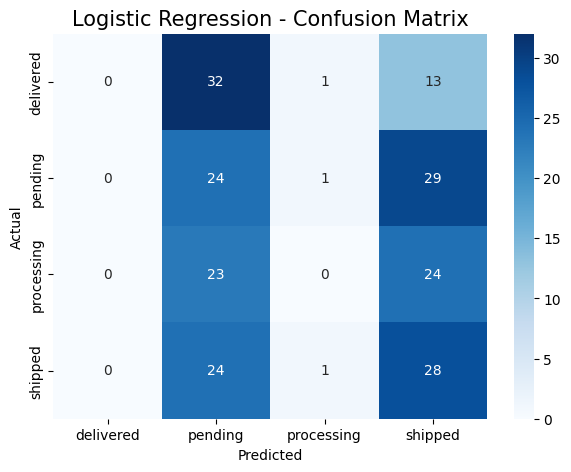


Decision Tree

Classification Report:

              precision    recall  f1-score   support

   delivered       0.22      0.28      0.25        46
     pending       0.18      0.19      0.18        54
  processing       0.11      0.09      0.10        47
     shipped       0.24      0.23      0.23        53

    accuracy                           0.20       200
   macro avg       0.19      0.19      0.19       200
weighted avg       0.19      0.20      0.19       200



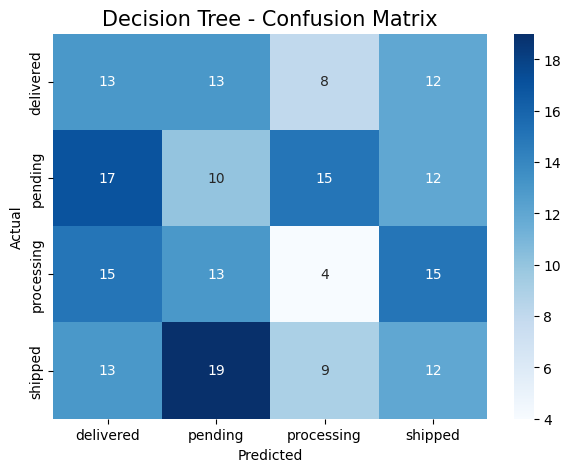


Random Forest

Classification Report:

              precision    recall  f1-score   support

   delivered       0.23      0.39      0.29        46
     pending       0.20      0.09      0.13        54
  processing       0.22      0.04      0.07        47
     shipped       0.23      0.38      0.28        53

    accuracy                           0.23       200
   macro avg       0.22      0.23      0.19       200
weighted avg       0.22      0.23      0.19       200



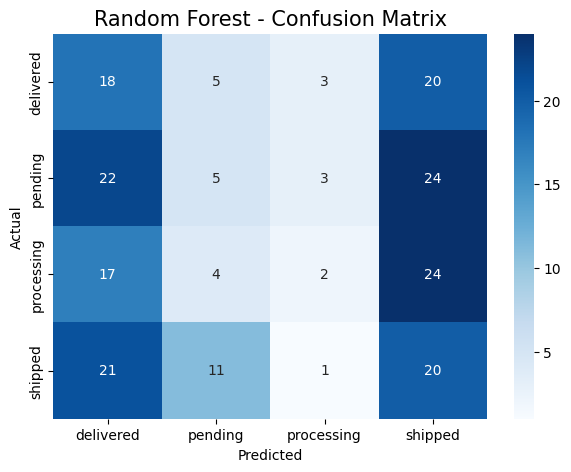


Gradient Boosting

Classification Report:

              precision    recall  f1-score   support

   delivered       0.18      0.30      0.22        46
     pending       0.40      0.04      0.07        54
  processing       0.17      0.06      0.09        47
     shipped       0.27      0.49      0.34        53

    accuracy                           0.23       200
   macro avg       0.25      0.22      0.18       200
weighted avg       0.26      0.23      0.18       200



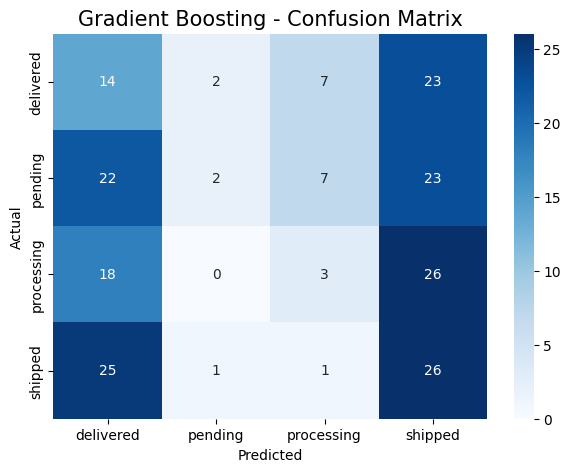


KNN

Classification Report:

              precision    recall  f1-score   support

   delivered       0.26      0.35      0.30        46
     pending       0.23      0.28      0.25        54
  processing       0.23      0.15      0.18        47
     shipped       0.21      0.17      0.19        53

    accuracy                           0.23       200
   macro avg       0.23      0.24      0.23       200
weighted avg       0.23      0.23      0.23       200



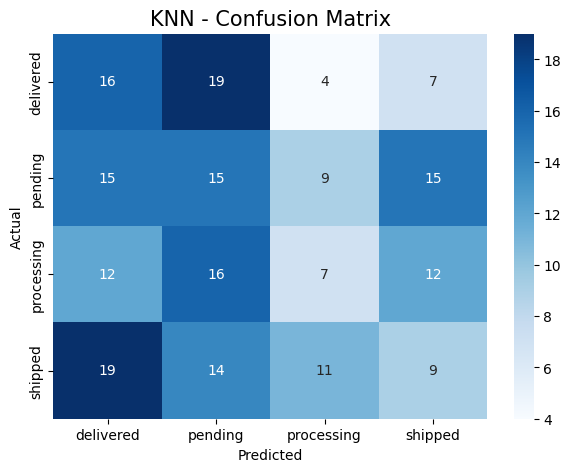


XGBoost

Classification Report:

              precision    recall  f1-score   support

   delivered       0.23      0.59      0.33        46
     pending       0.11      0.04      0.06        54
  processing       0.21      0.09      0.12        47
     shipped       0.29      0.25      0.27        53

    accuracy                           0.23       200
   macro avg       0.21      0.24      0.19       200
weighted avg       0.21      0.23      0.19       200



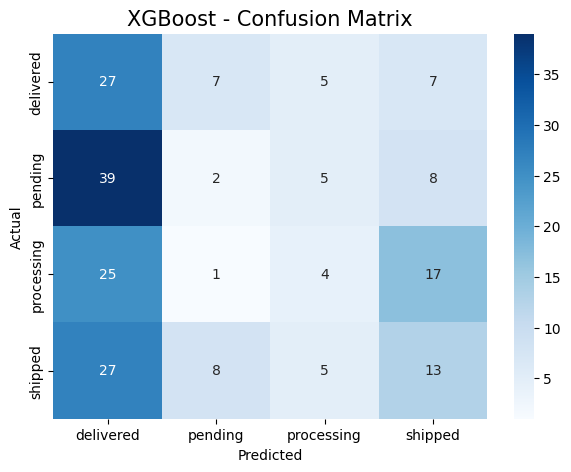


LightGBM

Classification Report:

              precision    recall  f1-score   support

   delivered       0.22      0.54      0.31        46
     pending       0.26      0.17      0.20        54
  processing       0.33      0.11      0.16        47
     shipped       0.31      0.21      0.25        53

    accuracy                           0.25       200
   macro avg       0.28      0.26      0.23       200
weighted avg       0.28      0.25      0.23       200



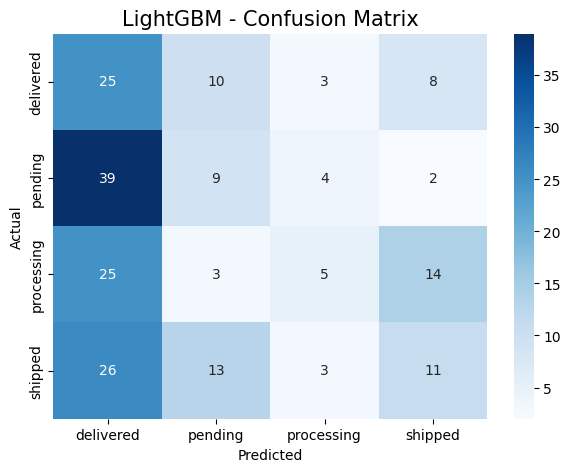


MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,26.00%,14.18%,26.00%,18.35%
6,LightGBM,25.00%,28.10%,25.00%,23.02%
4,KNN,23.50%,23.12%,23.50%,22.87%
5,XGBoost,23.00%,20.87%,23.00%,18.95%
2,Random Forest,22.50%,21.95%,22.50%,19.29%
3,Gradient Boosting,22.50%,25.82%,22.50%,18.28%
1,Decision Tree,19.50%,18.91%,19.50%,19.08%


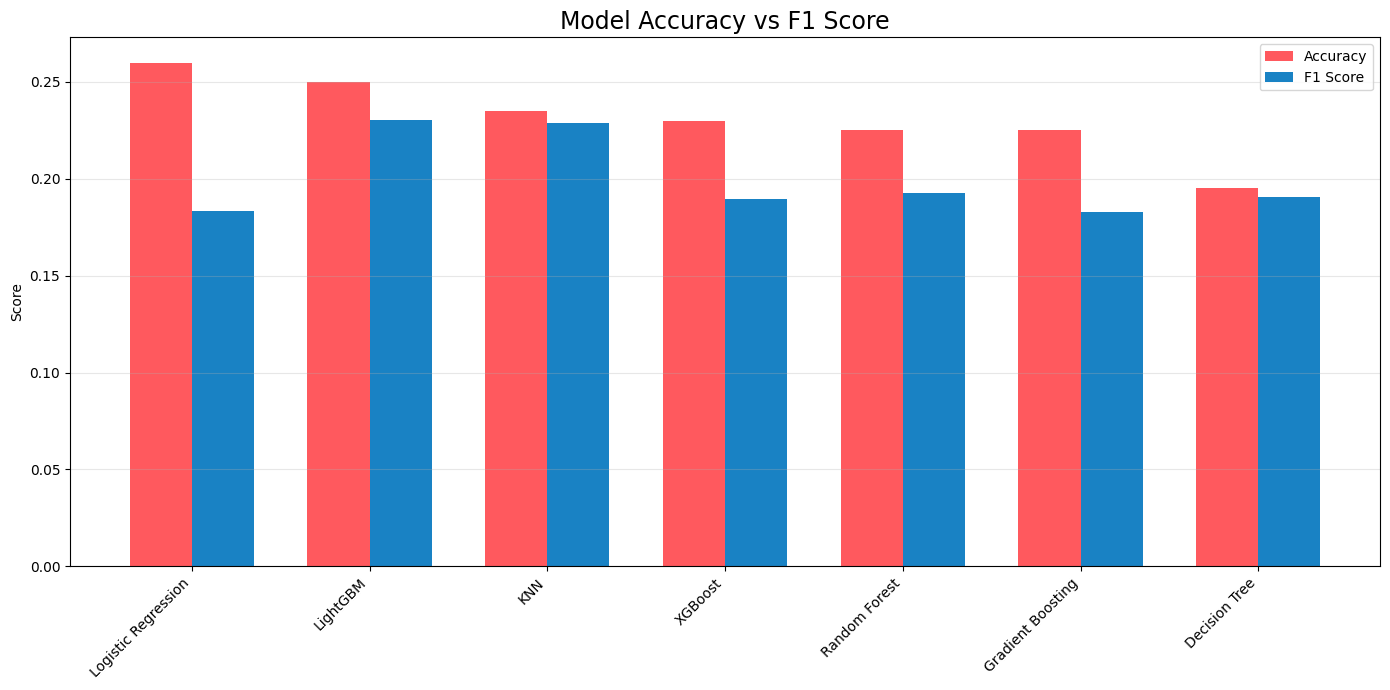

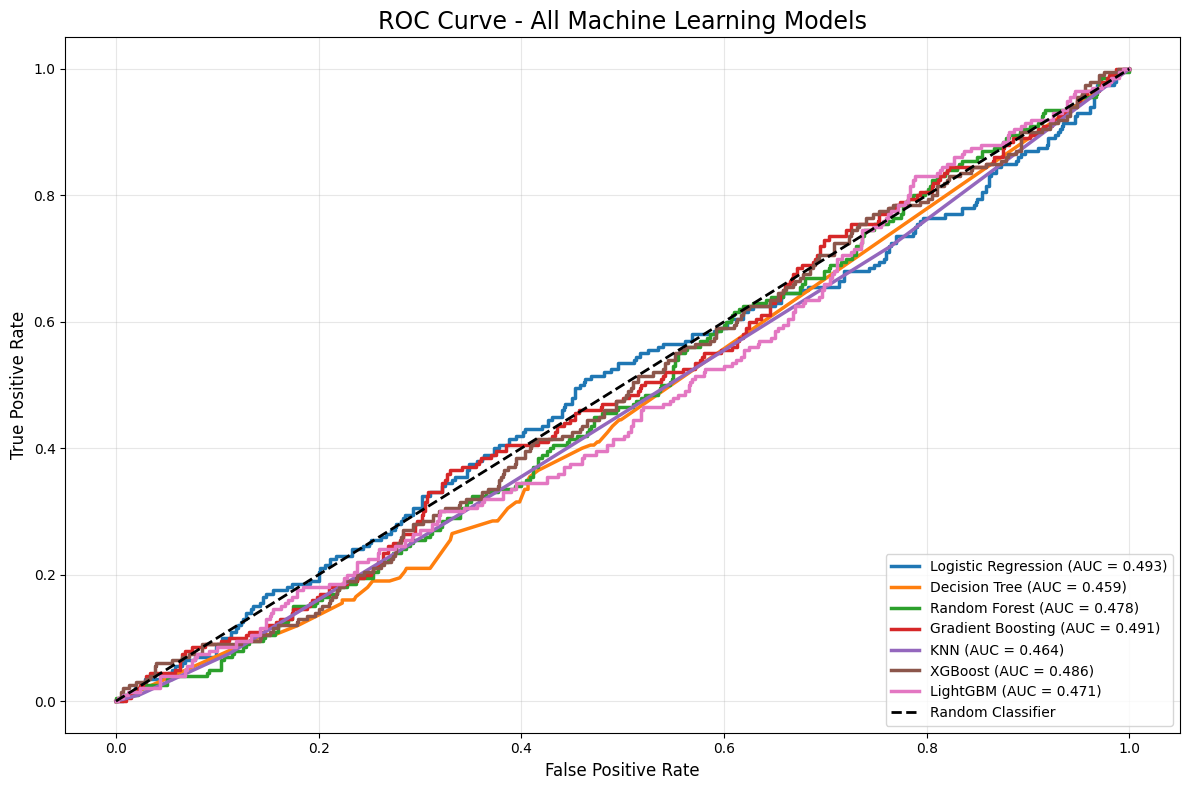


ROC-AUC RESULTS


,Model,ROC-AUC
5,XGBoost,0.4938
3,Gradient Boosting,0.4899
6,LightGBM,0.4713
2,Random Forest,0.4665
4,KNN,0.4600
1,Decision Tree,0.4580
0,Logistic Regression,0.4403



BEST MACHINE LEARNING MODEL
Model     : Logistic Regression
Accuracy  : 26.00%
Precision : 14.18%
Recall    : 26.00%
F1 Score  : 18.35%
ROC-AUC   : 0.4403

Target classes:
['delivered' 'pending' 'processing' 'shipped']

SUCCESS: Complete ML pipeline finished.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize

# ============================================================
# 1. LOAD DATA
# ============================================================

path = "/kaggle/input/datasets/udaykumar025/retails-sales-analysis/Retail Sales Analysis/Retail Sales Analysis/"

customer = pd.read_csv(path + "customer.csv")
product = pd.read_csv(path + "product.csv")
order = pd.read_csv(path + "order.csv")
calendar = pd.read_csv(path + "clander.csv")

# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

for data in [customer, product, order, calendar]:

    data.columns = (
        data.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    data.drop_duplicates(inplace=True)

# Remove unwanted columns
customer.drop(
    columns=["unnamed:_6"],
    errors="ignore",
    inplace=True
)

order.drop(
    columns=["unnamed:_6", "unnamed:_7", "unnamed:_8"],
    errors="ignore",
    inplace=True
)

calendar.drop(
    columns=["unnamed:_7", "unnamed:_8"],
    errors="ignore",
    inplace=True
)

# ============================================================
# 3. CREATE ML DATASET
# ============================================================

data = order.copy()

# Target
target = "orderstatus"

# Remove columns that should not be used
drop_cols = [
    "orderstatus",
    "shipaddress"
]

X = data.drop(
    columns=drop_cols,
    errors="ignore"
)

y = data[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

# ============================================================
# 4. FIND DATETIME COLUMNS
# ============================================================

datetime_columns = X.select_dtypes(
    include=["datetime64[ns]", "datetime64[ns, UTC]"]
).columns.tolist()

print("\nDatetime columns:")
print(datetime_columns)

# ============================================================
# 5. CONVERT DATETIME TO NUMERIC FEATURES
# ============================================================

for col in datetime_columns:

    X[col + "_year"] = X[col].dt.year
    X[col + "_month"] = X[col].dt.month
    X[col + "_day"] = X[col].dt.day
    X[col + "_dayofweek"] = X[col].dt.dayofweek

    # Remove original datetime column
    X.drop(
        columns=[col],
        inplace=True
    )

# ============================================================
# 6. FIND CATEGORICAL COLUMNS
# ============================================================

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=np.number
).columns.tolist()

print("\nCategorical columns:")
print(categorical_columns)

print("\nNumeric columns:")
print(numeric_columns)

# ============================================================
# 7. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining:", X_train.shape)
print("Testing :", X_test.shape)

# ============================================================
# 8. LABEL ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)

y_test = target_encoder.transform(y_test)

print("\nTarget classes:")
print(
    dict(
        enumerate(
            target_encoder.classes_
        )
    )
)

# ============================================================
# 9. LABEL ENCODE CATEGORICAL FEATURES
# ============================================================

encoders = {}

for col in categorical_columns:

    encoder = LabelEncoder()

    # Training values
    train_values = (
        X_train[col]
        .fillna("Missing")
        .astype(str)
    )

    # Testing values
    test_values = (
        X_test[col]
        .fillna("Missing")
        .astype(str)
    )

    # Fit only on training data
    encoder.fit(train_values)

    # Handle unseen test categories
    known_values = set(
        encoder.classes_
    )

    test_values = test_values.apply(
        lambda x:
        x if x in known_values
        else encoder.classes_[0]
    )

    X_train[col] = encoder.transform(
        train_values
    )

    X_test[col] = encoder.transform(
        test_values
    )

    encoders[col] = encoder

# ============================================================
# 10. CONVERT EVERYTHING TO NUMERIC
# ============================================================

for col in X_train.columns:

    X_train[col] = pd.to_numeric(
        X_train[col],
        errors="coerce"
    )

    X_test[col] = pd.to_numeric(
        X_test[col],
        errors="coerce"
    )

# ============================================================
# 11. HANDLE MISSING VALUES
# ============================================================

for col in X_train.columns:

    median_value = X_train[col].median()

    if pd.isna(median_value):
        median_value = 0

    X_train[col] = X_train[col].fillna(
        median_value
    )

    X_test[col] = X_test[col].fillna(
        median_value
    )

# ============================================================
# 12. FINAL DATATYPE CHECK
# ============================================================

print("\nFinal data types:")
print(X_train.dtypes)

print(
    "\nNon-numeric columns:",
    X_train.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

# ============================================================
# 13. STANDARD SCALER
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("\nScaling completed successfully.")

# ============================================================
# 14. CREATE MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        )
}

# ============================================================
# 15. XGBOOST
# ============================================================

try:

    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42
    )

except Exception as e:

    print(
        "XGBoost skipped:",
        e
    )

# ============================================================
# 16. LIGHTGBM
# ============================================================

try:

    from lightgbm import LGBMClassifier

    models["LightGBM"] = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8,
        verbosity=-1,
        random_state=42
    )

except Exception as e:

    print(
        "LightGBM skipped:",
        e
    )

# ============================================================
# 17. TRAIN ALL MODELS
# ============================================================

results = []
trained_models = {}
model_probabilities = {}

for name, model in models.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    # Train
    model.fit(
        X_train_scaled,
        y_train
    )

    # Predict
    y_pred = model.predict(
        X_test_scaled
    )

    # Probability
    y_prob = model.predict_proba(
        X_test_scaled
    )

    model_probabilities[name] = y_prob

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[name] = model

    # ========================================================
    # Classification Report
    # ========================================================

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=target_encoder.classes_,
            zero_division=0
        )
    )

    # ========================================================
    # Confusion Matrix
    # ========================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_
    )

    plt.title(
        f"{name} - Confusion Matrix",
        fontsize=15
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# ============================================================
# 18. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results
).sort_values(
    "Accuracy",
    ascending=False
)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}"
    })
)

# ============================================================
# 19. ACCURACY / F1 COMPARISON
# ============================================================

x = np.arange(
    len(results_df)
)

width = 0.35

plt.figure(figsize=(14, 7))

plt.bar(
    x - width / 2,
    results_df["Accuracy"],
    width,
    label="Accuracy",
    color="#FF595E"
)

plt.bar(
    x + width / 2,
    results_df["F1 Score"],
    width,
    label="F1 Score",
    color="#1982C4"
)

plt.xticks(
    x,
    results_df["Model"],
    rotation=45,
    ha="right"
)

plt.ylabel("Score")
plt.title(
    "Model Accuracy vs F1 Score",
    fontsize=17
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# 20. ROC CURVE
# ============================================================

n_classes = len(
    target_encoder.classes_
)

plt.figure(figsize=(12, 8))

for name, y_prob in model_probabilities.items():

    # --------------------------------------------------------
    # Binary classification
    # --------------------------------------------------------

    if n_classes == 2:

        fpr, tpr, _ = roc_curve(
            y_test,
            y_prob[:, 1]
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2.5,
            label=f"{name} (AUC = {roc_auc:.3f})"
        )

    # --------------------------------------------------------
    # Multiclass classification
    # --------------------------------------------------------

    else:

        y_test_binary = label_binarize(
            y_test,
            classes=np.arange(n_classes)
        )

        fpr_micro, tpr_micro, _ = roc_curve(
            y_test_binary.ravel(),
            y_prob.ravel()
        )

        roc_auc_micro = auc(
            fpr_micro,
            tpr_micro
        )

        plt.plot(
            fpr_micro,
            tpr_micro,
            linewidth=2.5,
            label=f"{name} (AUC = {roc_auc_micro:.3f})"
        )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "ROC Curve - All Machine Learning Models",
    fontsize=17
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# 21. ROC-AUC TABLE
# ============================================================

roc_results = []

for name, y_prob in model_probabilities.items():

    if n_classes == 2:

        score = roc_auc_score(
            y_test,
            y_prob[:, 1]
        )

    else:

        score = roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )

    roc_results.append({
        "Model": name,
        "ROC-AUC": score
    })

roc_df = pd.DataFrame(
    roc_results
).sort_values(
    "ROC-AUC",
    ascending=False
)

print("\n" + "=" * 60)
print("ROC-AUC RESULTS")
print("=" * 60)

display(
    roc_df.style.format({
        "ROC-AUC": "{:.4f}"
    })
)

# ============================================================
# 22. BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_accuracy = results_df.iloc[0]["Accuracy"]
best_precision = results_df.iloc[0]["Precision"]
best_recall = results_df.iloc[0]["Recall"]
best_f1 = results_df.iloc[0]["F1 Score"]

best_auc = roc_df[
    roc_df["Model"] == best_model_name
]["ROC-AUC"].iloc[0]

print("\n" + "=" * 70)
print("BEST MACHINE LEARNING MODEL")
print("=" * 70)

print("Model     :", best_model_name)
print("Accuracy  :", f"{best_accuracy:.2%}")
print("Precision :", f"{best_precision:.2%}")
print("Recall    :", f"{best_recall:.2%}")
print("F1 Score  :", f"{best_f1:.2%}")
print("ROC-AUC   :", f"{best_auc:.4f}")

print("\nTarget classes:")
print(target_encoder.classes_)

print("\nSUCCESS: Complete ML pipeline finished.")

## Thank you..pls upvote!!!!!!!!!!